In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
print("✅ Libraries loaded")


✅ Libraries loaded


In [33]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nChurn Distribution:\n{df['Churn'].value_counts(normalize=True)*100}")
df.head()


Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# Fix TotalCharges — stored as string with spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill nulls in TotalCharges (new customers with 0 tenure)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn to binary 0/1
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

df_clean = df.copy()

# Verify no more nulls
print(f"Nulls remaining: {df_clean.isnull().sum().sum()}")
df_clean.to_csv('../data/processed/telco_cleaned.csv', index=False)
print("✅ Cleaned data saved (customerID retained)")
print(f"Columns in saved file: {list(df_clean.columns)}")

Nulls remaining: 0
✅ Cleaned data saved (customerID retained)
Columns in saved file: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary']


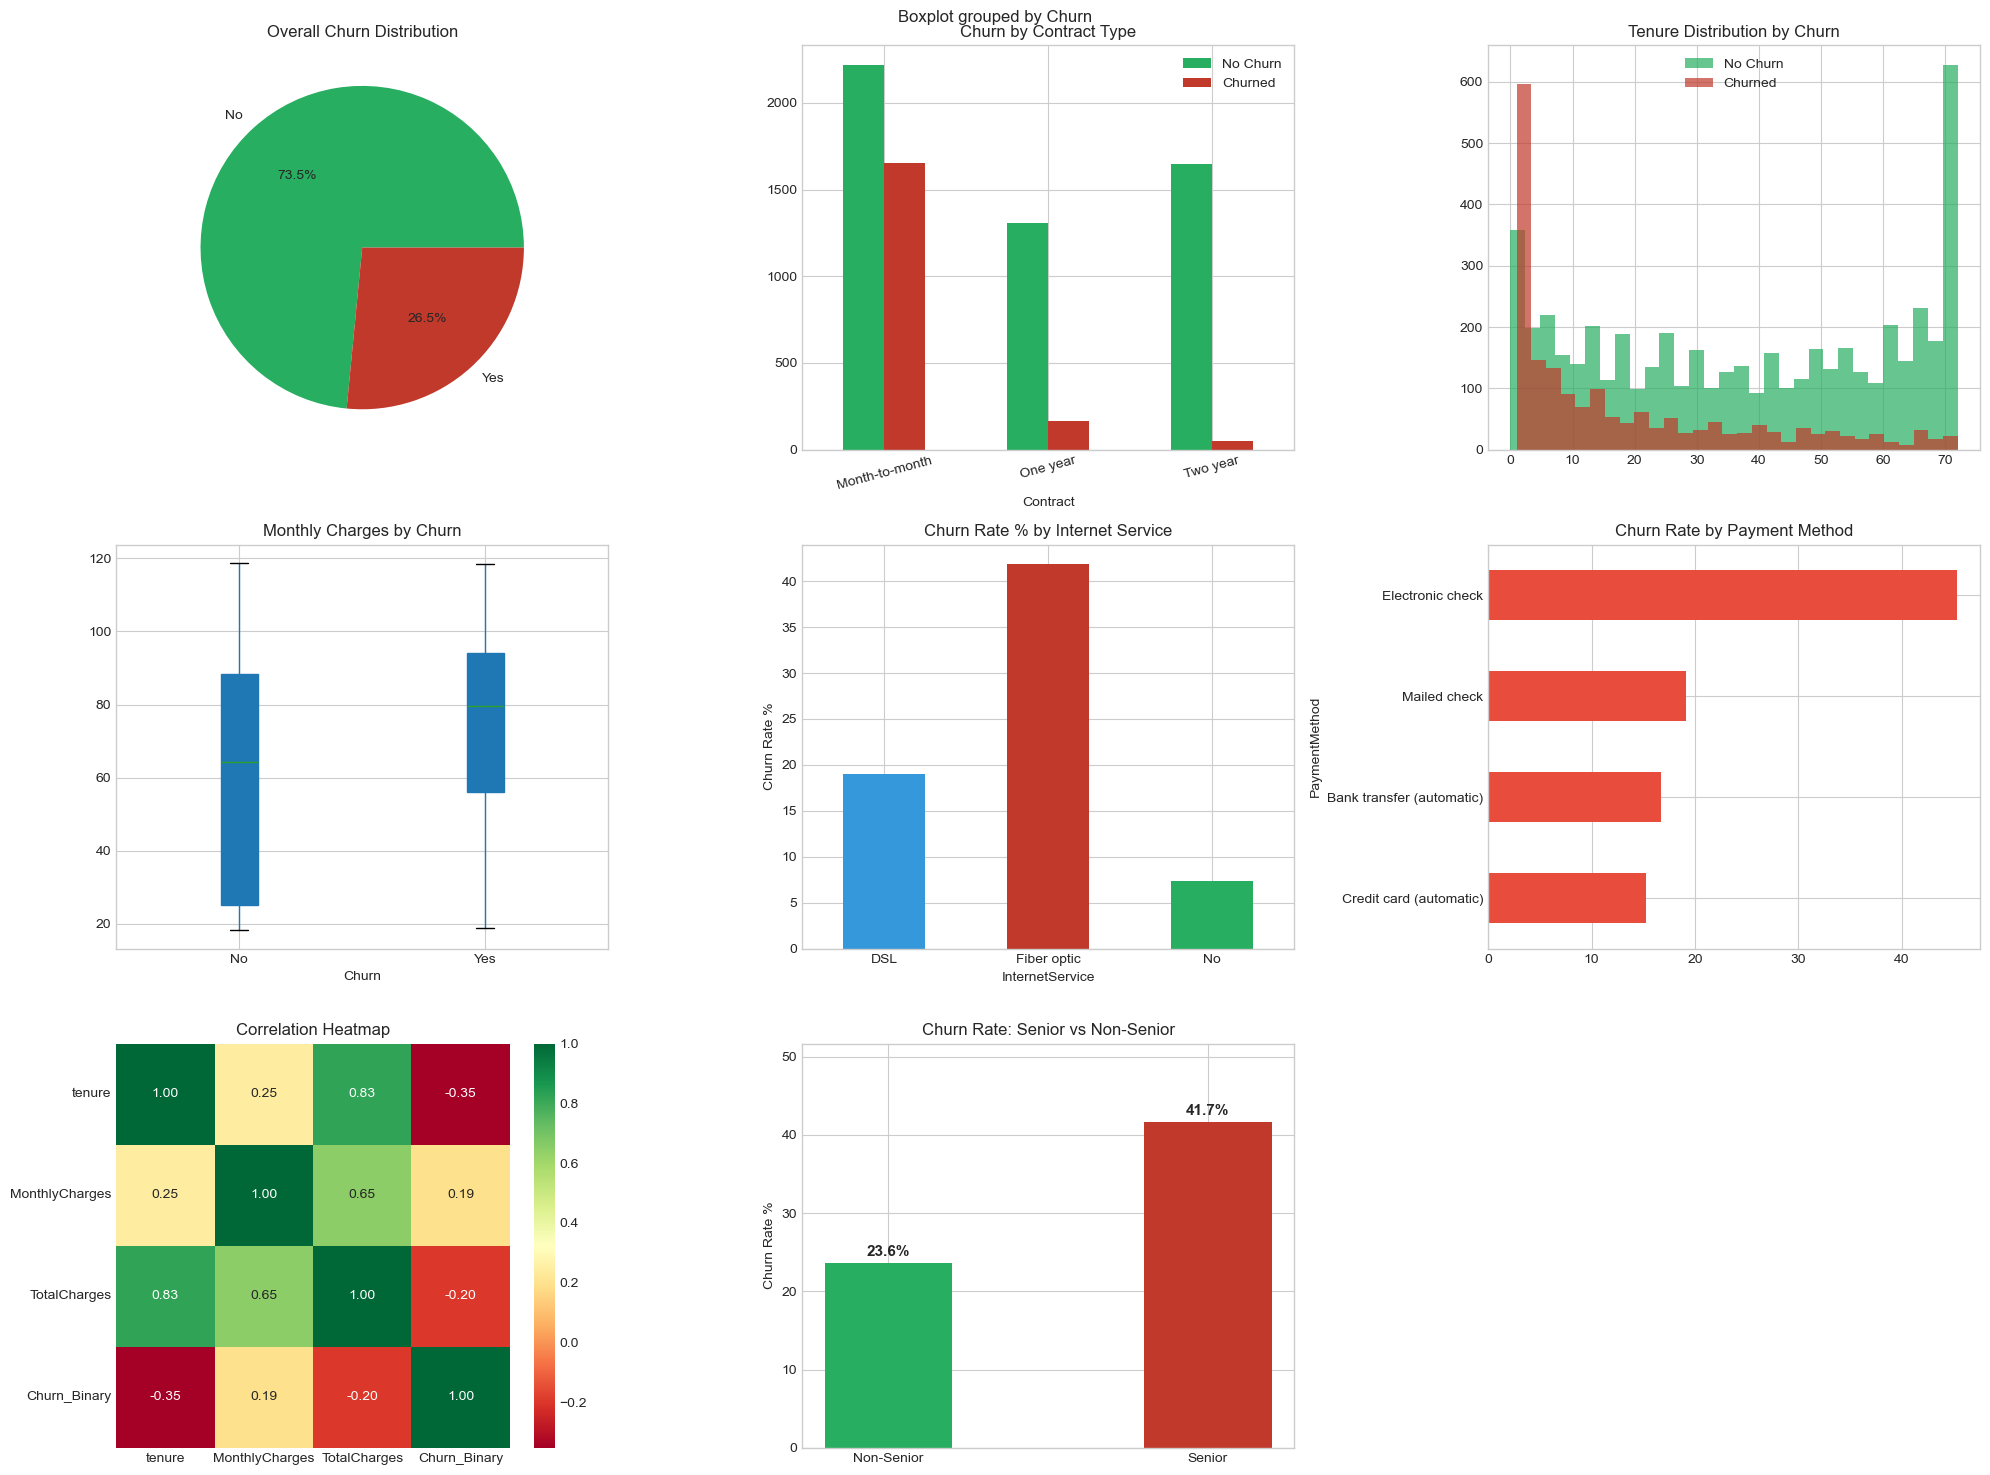

✅ EDA charts saved to reports/


In [35]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Customer Churn — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Churn Distribution (Pie)
churn_counts = df_clean['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=churn_counts.index,
              autopct='%1.1f%%',
              colors=['#27ae60', '#c0392b'])
axes[0,0].set_title('Overall Churn Distribution')

# 2. Churn by Contract Type
contract_churn = df_clean.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[0,1],
                    color=['#27ae60', '#c0392b'], rot=15)
axes[0,1].set_title('Churn by Contract Type')
axes[0,1].legend(['No Churn', 'Churned'])

# 3. Tenure Distribution by Churn
df_clean[df_clean['Churn'] == 'No']['tenure'].hist(
    ax=axes[0,2], alpha=0.7, color='#27ae60', label='No Churn', bins=30)
df_clean[df_clean['Churn'] == 'Yes']['tenure'].hist(
    ax=axes[0,2], alpha=0.7, color='#c0392b', label='Churned', bins=30)
axes[0,2].set_title('Tenure Distribution by Churn')
axes[0,2].legend()

# 4. Monthly Charges Boxplot
df_clean.boxplot(column='MonthlyCharges', by='Churn',
                 ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Monthly Charges by Churn')

# 5. Internet Service Churn Rate
int_churn = df_clean.groupby('InternetService')['Churn_Binary'].mean() * 100
int_churn.plot(kind='bar', ax=axes[1,1],
               color=['#3498db', '#c0392b', '#27ae60'], rot=0)
axes[1,1].set_title('Churn Rate % by Internet Service')
axes[1,1].set_ylabel('Churn Rate %')


# 6. Payment Method Churn
pay_churn = df_clean.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
pay_churn.sort_values().plot(kind='barh', ax=axes[1,2], color='#e74c3c')
axes[1,2].set_title('Churn Rate by Payment Method')

# 7. Correlation Heatmap (numeric cols)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
sns.heatmap(df_clean[num_cols].corr(), ax=axes[2,0],
            annot=True, fmt='.2f', cmap='RdYlGn')
axes[2,0].set_title('Correlation Heatmap')

# 8. Senior Citizen Churn Rate
senior_churn = df_clean.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
labels = ['Non-Senior' if i == 0 else 'Senior' for i in senior_churn.index]
bar_colors = ['#27ae60', '#c0392b'][:len(senior_churn)]

bars = axes[2,1].bar(labels, senior_churn.values, color=bar_colors, width=0.4)

# Add percentage labels on top of bars
for bar, val in zip(bars, senior_churn.values):
    axes[2,1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

axes[2,1].set_title('Churn Rate: Senior vs Non-Senior')
axes[2,1].set_ylabel('Churn Rate %')
axes[2,1].set_ylim(0, senior_churn.values.max() + 10)

axes[2,2].axis('off')
plt.tight_layout()
plt.savefig('../reports/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved to reports/")